# Entrenamiento de segmentacion: binary spine y thoracolumbar

Este notebook deja un pipeline base y reutilizable para entrenar dos tareas:

1. `binary spine`: columna vs fondo usando todas las imagenes utilizables.
2. `thoracolumbar multiclass`: deteccion por vertebra solo para `T1..T12` y `L1..L5`.

El diseno esta alineado con la decision del proyecto:

- excluir cervicales (`C3..C7`) del target
- usarlas como `ignore` en la mascara multiclase, no como fondo
- partir el dataset en `80% train` y `20% test`
- calcular metricas dentro del mismo notebook para analizar el entrenamiento

## Antes de ejecutar

1. Abre el notebook desde la raiz del proyecto o desde `notebooks/`.
2. Verifica que exista:
   - `Scoliosis_Dataset_V3/Scoliosis_Dataset/indice_dataset.csv`
   - `Scoliosis_Dataset_V3/Scoliosis_Dataset/diccionario_etiquetas_T1_T12_L1_L5.json`
   - `analysis_outputs_v3/training_manifest_thoracolumbar_v3.csv`
3. Si tu ambiente aun no tiene PyTorch, instala primero:

```python
%pip install -r requirements-notebook.txt
%pip install torch torchvision torchaudio
```

Notas practicas:

- Por defecto el notebook entrena multiclase sobre `thoracolumbar_core`.
- Si luego quieres ampliar a muestras parciales, solo cambia `MULTICLASS_SUBSET = 'partial'`.
- El split usa `group_id_for_split`, para evitar fuga de informacion entre train y test.

In [1]:
%pip install -r requirements-notebook.txt

  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   --- ------------------------------------ 1.1/12.4 MB 24.7 MB/s eta 0:00:01
   ------- -------------------------------- 2.3/12.4 MB 24.8 MB/s eta 0:00:01
   ----------- ---------------------------- 3.5/12.4 MB 25.2 MB/s eta 0:00:01
   --------------- ------------------------ 4.9/12.4 MB 26.3 MB/s eta 0:00:01
   --------------------- ------------------ 6.6/12.4 MB 30.1 MB/s eta 0:00:01
   -------------------------- ------------- 8.4/12.4 MB 31.5 MB/s eta 0:00:01
   --------------------------------- ------ 10.5/12.4 MB 34.4 MB/s eta 0:00:01
   ---------------------------------------  12.4/12.4 MB 36.4 MB/s eta 0:00:01
   ---------------------------------------  12.4/12.4 MB 36.4 MB/s eta 0:00:01
   ---------------------------------------  12.4/12.4 MB 36.4 MB/s eta 0:00:01
   ------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
spyder-kernels 2.5.0 requires ipykernel<7,>=6.23.2; python_version >= "3.8", but you have ipykernel 7.2.0 which is incompatible.


In [2]:
%pip install torch torchvision torchaudio

In [3]:
from __future__ import annotations

import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

def _resolve_maia_project_root(marker: Path) -> Path:
    """Raiz del repo (carpeta que contiene marker). Local, subcarpetas, Colab+Drive."""
    env = os.environ.get('MAIA_PROJECT_ROOT', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / marker).exists():
            return p
    cwd = Path.cwd().resolve()
    for cand in [cwd, *cwd.parents]:
        if (cand / marker).exists():
            return cand
    drive_nb = Path('/content/drive/MyDrive/Colab Notebooks')
    if drive_nb.is_dir():
        direct = drive_nb / 'MAIA-PROYECTO'
        if (direct / marker).exists():
            return direct.resolve()
        for child in drive_nb.iterdir():
            try:
                if child.is_dir() and (child / marker).exists():
                    return child.resolve()
            except OSError:
                continue
    drive_maia = Path('/content/drive/MyDrive/MAIA-PROYECTO')
    if (drive_maia / marker).exists():
        return drive_maia.resolve()
    raise FileNotFoundError(
        f"No se encontro {marker.as_posix()}. Opciones: (1) %cd a la raiz del repo; "
        f"(2) os.environ['MAIA_PROJECT_ROOT'] = r'.../MAIA-PROYECTO'. cwd={cwd}"
    )


ROOT = _resolve_maia_project_root(Path('data') / 'Scoliosis_Dataset')

DATASET_DIR = ROOT / 'data' / 'Scoliosis_Dataset'
DATASET_INDEX_PATH = DATASET_DIR / 'indice_dataset.csv'
LABELS_DICT_PATH = DATASET_DIR / 'diccionario_etiquetas_T1_T12_L1_L5.json'
MANIFEST_PATH = ROOT / 'outputs' / 'analysis_outputs_v3' / 'training_manifest_thoracolumbar_v3.csv'
OUTPUT_DIR = ROOT / 'outputs' / 'analysis_outputs_v3' / 'training_runs_v3'
MODEL_DIR = ROOT / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'

IMG_SIZE = (512, 256)
BATCH_SIZE = 4
NUM_WORKERS = 0
LR = 1e-3
WEIGHT_DECAY = 1e-4
BINARY_EPOCHS = 12
MULTICLASS_EPOCHS = 18
TRAIN_RATIO = 0.80
IGNORE_INDEX = 255
MULTICLASS_SUBSET = 'core'   # usar 'partial' cuando quieras ampliar el entrenamiento

TARGET_LABELS = [f'T{i}' for i in range(1, 13)] + [f'L{i}' for i in range(1, 6)]
EXCLUDED_LABELS = ['C7', 'C6', 'C5', 'C4', 'C3']

dataset_index_df = pd.read_csv(DATASET_INDEX_PATH)
# Normalizar esquema del indice V3 para compatibilidad con el pipeline.
dataset_index_df = dataset_index_df.rename(columns={
    'grupo': 'split',
    'imagen': 'image',
    'id_paciente': 'patient_id',
    'ruta_radiografia': 'radiograph_path',
    'ruta_mascara_binaria': 'label_binary_path',
    'ruta_mascara_multiclase_id_png': 'multiclass_path',
})
dataset_index_df['mask_path'] = dataset_index_df['multiclass_path']
manifest_df = pd.read_csv(MANIFEST_PATH)
with open(LABELS_DICT_PATH, 'r', encoding='utf-8') as f:
    labels_dict = json.load(f)

multiclass_key = 'multiclass_id_png' if 'multiclass_id_png' in labels_dict else 'mascara_multiclase_id_png'
multiclass_map = {int(k): v for k, v in labels_dict[multiclass_key].items()}
label_to_id = {label: class_id for class_id, label in multiclass_map.items()}
target_id_to_train_id = {label_to_id[label]: idx + 1 for idx, label in enumerate(TARGET_LABELS)}
class_names = ['background'] + TARGET_LABELS
num_classes = len(class_names)

join_cols = ['split', 'image', 'patient_id', 'radiograph_path']
dataset_subset = dataset_index_df[join_cols + ['label_binary_path', 'multiclass_path']].copy()
train_table = manifest_df.merge(dataset_subset, on=join_cols, how='left', suffixes=('', '_idx'))

train_table['multiclass_path'] = train_table['mask_path'].fillna(train_table['multiclass_path'])
train_table['radiograph_path_abs'] = train_table['radiograph_path'].apply(lambda rel: str((DATASET_DIR / rel).resolve()))
train_table['binary_mask_path_abs'] = train_table['label_binary_path'].apply(lambda rel: str((DATASET_DIR / rel).resolve()))
train_table['multiclass_mask_path_abs'] = train_table['multiclass_path'].apply(lambda rel: str((DATASET_DIR / rel).resolve()))

required_cols = [
    'unique_sample_id', 'group_id_for_split', 'split', 'image', 'patient_id',
    'radiograph_path_abs', 'binary_mask_path_abs', 'multiclass_mask_path_abs',
    'usable_for_binary_spine', 'usable_for_thoracolumbar_core', 'usable_for_thoracolumbar_partial',
    'needs_annotation_review'
]
missing_cols = [col for col in required_cols if col not in train_table.columns]
if missing_cols:
    raise ValueError(f'Faltan columnas en el manifest unido: {missing_cols}')

flag_cols = [
    'usable_for_binary_spine',
    'usable_for_thoracolumbar_core',
    'usable_for_thoracolumbar_partial',
    'needs_annotation_review',
    'usable_for_cobb_regression',
]
for col in flag_cols:
    if col in train_table.columns:
        train_table[col] = train_table[col].map(
            lambda x: x if isinstance(x, bool) else str(x).strip().lower() == 'true'
        )

missing_files = {
    'radiographs': int((~train_table['radiograph_path_abs'].map(lambda p: Path(p).exists())).sum()),
    'binary_masks': int((~train_table['binary_mask_path_abs'].map(lambda p: Path(p).exists())).sum()),
    'multiclass_masks': int((~train_table['multiclass_mask_path_abs'].map(lambda p: Path(p).exists())).sum()),
}
if any(missing_files.values()):
    raise FileNotFoundError(f'Hay archivos faltantes: {missing_files}')

print('ROOT:', ROOT)
print('DEVICE:', DEVICE)
print('Muestras totales del manifest:', len(train_table))
print('Subset binario utilizable:', int(train_table['usable_for_binary_spine'].sum()))
print('Subset thoracolumbar core:', int(train_table['usable_for_thoracolumbar_core'].sum()))
print('Subset thoracolumbar partial:', int(train_table['usable_for_thoracolumbar_partial'].sum()))
print('Casos con revision manual sugerida:', int(train_table['needs_annotation_review'].sum()))

display(
    train_table[
        [
            'unique_sample_id', 'split', 'image', 'group_id_for_split',
            'num_visible_target_vertebrae', 'visible_target_span_signature',
            'excluded_cervical_count', 'total_internal_missing_count',
            'unexpected_label_count', 'usable_for_binary_spine',
            'usable_for_thoracolumbar_core', 'usable_for_thoracolumbar_partial',
            'needs_annotation_review'
        ]
    ].head()
)


ROOT: C:\Users\JOHN\MAIA-PROYECTO
DEVICE: cpu
Muestras totales del manifest: 249
Subset binario utilizable: 249
Subset thoracolumbar core: 198
Subset thoracolumbar partial: 228
Casos con revision manual sugerida: 8


,unique_sample_id,split,image,group_id_for_split,num_visible_target_vertebrae,visible_target_span_signature,excluded_cervical_count,total_internal_missing_count,unexpected_label_count,usable_for_binary_spine,usable_for_thoracolumbar_core,usable_for_thoracolumbar_partial,needs_annotation_review
0,Normal__N_1.jpg,Normal,N_1.jpg,Normal_1,17,T1-L5,0,0,0,True,True,True,False
1,Normal__N_2.jpg,Normal,N_2.jpg,Normal_2,17,T1-L5,0,0,0,True,True,True,False
2,Normal__N_3.jpg,Normal,N_3.jpg,Normal_3,17,T1-L5,0,0,0,True,True,True,False
3,Normal__N_4.jpg,Normal,N_4.jpg,Normal_4,17,T1-L5,0,0,0,True,True,True,False
4,Normal__N_5.jpg,Normal,N_5.jpg,Normal_5,17,T1-L5,0,0,0,True,True,True,False


In [4]:
def make_train_test_split(df_in: pd.DataFrame, train_ratio: float = 0.80, seed: int = 42) -> pd.DataFrame:
    work = df_in.reset_index(drop=True).copy()
    splitter = GroupShuffleSplit(n_splits=1, train_size=train_ratio, random_state=seed)
    train_idx, test_idx = next(splitter.split(work, groups=work['group_id_for_split']))
    train_df = work.iloc[train_idx].copy()
    test_df = work.iloc[test_idx].copy()
    train_df['partition'] = 'train'
    test_df['partition'] = 'test'
    return pd.concat([train_df, test_df], ignore_index=True)


binary_df = train_table.loc[train_table['usable_for_binary_spine']].copy()
multiclass_flag = 'usable_for_thoracolumbar_core' if MULTICLASS_SUBSET == 'core' else 'usable_for_thoracolumbar_partial'
multiclass_df = train_table.loc[train_table[multiclass_flag] & ~train_table['needs_annotation_review']].copy()

binary_splits_df = make_train_test_split(binary_df, train_ratio=TRAIN_RATIO, seed=SEED)
multiclass_splits_df = make_train_test_split(multiclass_df, train_ratio=TRAIN_RATIO, seed=SEED)

binary_split_path = OUTPUT_DIR / 'binary_spine_split_80_20.csv'
multiclass_split_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_split_80_20.csv'
binary_splits_df.to_csv(binary_split_path, index=False)
multiclass_splits_df.to_csv(multiclass_split_path, index=False)

print('Split binario guardado en:', binary_split_path)
print('Split multiclase guardado en:', multiclass_split_path)

print('\nDistribucion binaria por particion:')
display(binary_splits_df['partition'].value_counts().rename_axis('partition').reset_index(name='images'))
display(binary_splits_df.groupby(['partition', 'split']).size().rename('images').reset_index())

print('\nDistribucion multiclase por particion:')
display(multiclass_splits_df['partition'].value_counts().rename_axis('partition').reset_index(name='images'))
display(multiclass_splits_df.groupby(['partition', 'split']).size().rename('images').reset_index())

assert set(binary_splits_df['partition']) == {'train', 'test'}
assert set(multiclass_splits_df['partition']) == {'train', 'test'}
assert set(binary_splits_df.loc[binary_splits_df['partition'] == 'train', 'group_id_for_split']).isdisjoint(
    set(binary_splits_df.loc[binary_splits_df['partition'] == 'test', 'group_id_for_split'])
)
assert set(multiclass_splits_df.loc[multiclass_splits_df['partition'] == 'train', 'group_id_for_split']).isdisjoint(
    set(multiclass_splits_df.loc[multiclass_splits_df['partition'] == 'test', 'group_id_for_split'])
)

Split binario guardado en: C:\Users\JOHN\MAIA-PROYECTO\analysis_outputs_v3\training_runs_v3\binary_spine_split_80_20.csv
Split multiclase guardado en: C:\Users\JOHN\MAIA-PROYECTO\analysis_outputs_v3\training_runs_v3\thoracolumbar_core_split_80_20.csv

Distribucion binaria por particion:


,partition,images
0,train,199
1,test,50


,partition,split,images
0,test,Normal,18
1,test,Scoliosis,32
2,train,Normal,53
3,train,Scoliosis,146



Distribucion multiclase por particion:


,partition,images
0,train,158
1,test,40


,partition,split,images
0,test,Normal,11
1,test,Scoliosis,29
2,train,Normal,53
3,train,Scoliosis,105


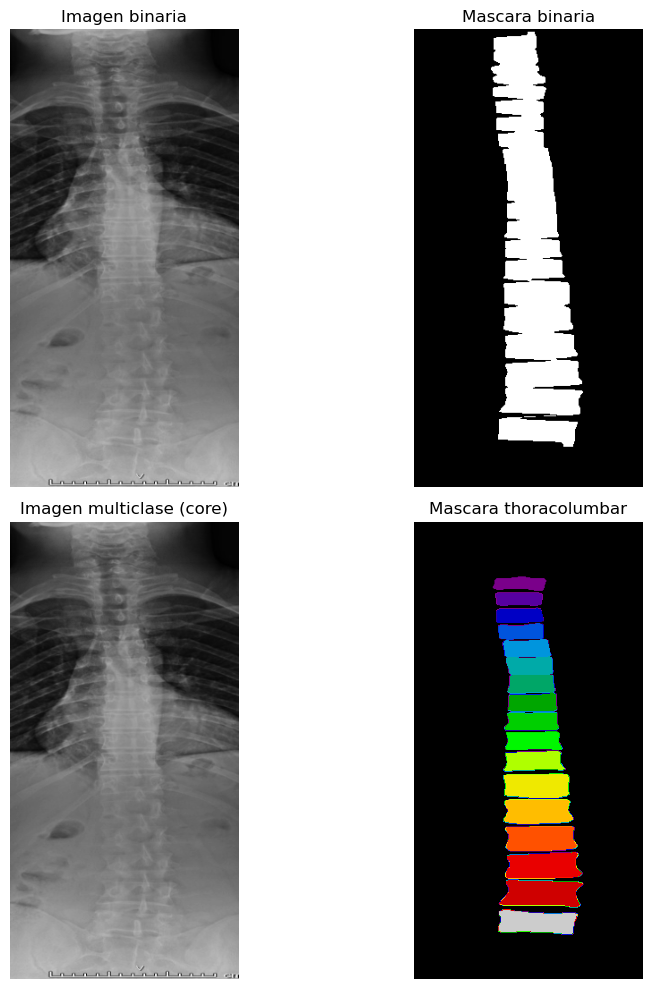

In [5]:
def read_gray(path: str) -> np.ndarray:
    return np.array(Image.open(path).convert('L'))


def resize_image(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr).resize((size[1], size[0]), resample=Image.BILINEAR))


def resize_mask(arr: np.ndarray, size: tuple[int, int]) -> np.ndarray:
    return np.array(Image.fromarray(arr.astype(np.uint8)).resize((size[1], size[0]), resample=Image.NEAREST))


def build_binary_mask(path: str, size: tuple[int, int]) -> np.ndarray:
    mask = read_gray(path)
    mask = (mask >= 127).astype(np.uint8)
    return resize_mask(mask, size)


def build_multiclass_mask(path: str, size: tuple[int, int]) -> np.ndarray:
    raw = np.array(Image.open(path), dtype=np.int32)
    out = np.zeros_like(raw, dtype=np.uint8)
    non_background = raw != 0
    out[non_background] = IGNORE_INDEX
    for old_id, new_id in target_id_to_train_id.items():
        out[raw == old_id] = new_id
    return resize_mask(out, size)


class SpineDataset(Dataset):
    def __init__(self, table: pd.DataFrame, task: str, image_size: tuple[int, int]):
        self.table = table.reset_index(drop=True).copy()
        self.task = task
        self.image_size = image_size

    def __len__(self) -> int:
        return len(self.table)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor | str]:
        row = self.table.iloc[idx]
        image = resize_image(read_gray(row['radiograph_path_abs']), self.image_size).astype(np.float32) / 255.0
        image = np.expand_dims(image, axis=0)
        if self.task == 'binary':
            mask = build_binary_mask(row['binary_mask_path_abs'], self.image_size).astype(np.float32)
            mask = np.expand_dims(mask, axis=0)
        else:
            mask = build_multiclass_mask(row['multiclass_mask_path_abs'], self.image_size).astype(np.int64)
        return {
            'image': torch.tensor(image, dtype=torch.float32),
            'mask': torch.tensor(mask),
            'sample_id': row['unique_sample_id'],
        }


binary_train_ds = SpineDataset(binary_splits_df.query("partition == 'train'"), task='binary', image_size=IMG_SIZE)
binary_test_ds = SpineDataset(binary_splits_df.query("partition == 'test'"), task='binary', image_size=IMG_SIZE)
multiclass_train_ds = SpineDataset(multiclass_splits_df.query("partition == 'train'"), task='multiclass', image_size=IMG_SIZE)
multiclass_test_ds = SpineDataset(multiclass_splits_df.query("partition == 'test'"), task='multiclass', image_size=IMG_SIZE)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
binary_sample = binary_train_ds[0]
multiclass_sample = multiclass_train_ds[0]

axes[0, 0].imshow(binary_sample['image'][0].numpy(), cmap='gray')
axes[0, 0].set_title('Imagen binaria')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_sample['mask'][0].numpy(), cmap='gray')
axes[0, 1].set_title('Mascara binaria')
axes[0, 1].axis('off')

axes[1, 0].imshow(multiclass_sample['image'][0].numpy(), cmap='gray')
axes[1, 0].set_title(f'Imagen multiclase ({MULTICLASS_SUBSET})')
axes[1, 0].axis('off')

axes[1, 1].imshow(multiclass_sample['mask'].numpy(), cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
axes[1, 1].set_title('Mascara thoracolumbar')
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class UNetSmall(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, base: int = 32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.e1 = DoubleConv(in_channels, base)
        self.e2 = DoubleConv(base, base * 2)
        self.e3 = DoubleConv(base * 2, base * 4)
        self.e4 = DoubleConv(base * 4, base * 8)
        self.b = DoubleConv(base * 8, base * 16)
        self.u4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.d4 = DoubleConv(base * 16, base * 8)
        self.u3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.d3 = DoubleConv(base * 8, base * 4)
        self.u2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.d2 = DoubleConv(base * 4, base * 2)
        self.u1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.d1 = DoubleConv(base * 2, base)
        self.head = nn.Conv2d(base, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))
        e4 = self.e4(self.pool(e3))
        b = self.b(self.pool(e4))

        d4 = self.u4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.d4(d4)

        d3 = self.u3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.d3(d3)

        d2 = self.u2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.d2(d2)

        d1 = self.u1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.d1(d1)
        return self.head(d1)


def dice_loss_binary(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(1, 2, 3))
    denom = probs.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denom + eps)
    return 1.0 - dice.mean()


def dice_loss_multiclass(
    logits: torch.Tensor,
    targets: torch.Tensor,
    num_classes: int,
    ignore_index: int = 255,
    eps: float = 1e-6,
) -> torch.Tensor:
    probs = torch.softmax(logits, dim=1)
    valid = targets != ignore_index
    safe_targets = targets.clone()
    safe_targets[~valid] = 0
    target_one_hot = F.one_hot(safe_targets, num_classes=num_classes).permute(0, 3, 1, 2).float()
    valid = valid.unsqueeze(1)
    probs = probs * valid
    target_one_hot = target_one_hot * valid

    probs = probs[:, 1:, :, :]
    target_one_hot = target_one_hot[:, 1:, :, :]

    intersection = (probs * target_one_hot).sum(dim=(0, 2, 3))
    denom = probs.sum(dim=(0, 2, 3)) + target_one_hot.sum(dim=(0, 2, 3))
    dice = (2.0 * intersection + eps) / (denom + eps)
    return 1.0 - dice.mean()


def evaluate_binary(model: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    bce = nn.BCEWithLogitsLoss()
    total_loss = 0.0
    total_batches = 0
    intersection = 0.0
    pred_area = 0.0
    target_area = 0.0
    correct = 0.0
    total_pixels = 0.0

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(DEVICE)
            targets = batch['mask'].to(DEVICE)
            logits = model(images)
            loss = bce(logits, targets) + dice_loss_binary(logits, targets)
            total_loss += float(loss.item())
            total_batches += 1

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            intersection += float((preds * targets).sum().item())
            pred_area += float(preds.sum().item())
            target_area += float(targets.sum().item())
            correct += float((preds == targets).sum().item())
            total_pixels += float(targets.numel())

    union = pred_area + target_area - intersection
    dice = (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
    iou = (intersection + 1e-6) / (union + 1e-6)
    pixel_accuracy = (correct + 1e-6) / (total_pixels + 1e-6)
    return {
        'loss': total_loss / max(total_batches, 1),
        'dice': dice,
        'iou': iou,
        'pixel_accuracy': pixel_accuracy,
    }


def evaluate_multiclass(model: nn.Module, loader: DataLoader, loss_fn: nn.Module) -> tuple[dict[str, float], pd.DataFrame]:
    model.eval()
    total_loss = 0.0
    total_batches = 0
    correct = 0.0
    total_valid_pixels = 0.0
    intersection = np.zeros(num_classes, dtype=np.float64)
    pred_area = np.zeros(num_classes, dtype=np.float64)
    target_area = np.zeros(num_classes, dtype=np.float64)

    with torch.no_grad():
        for batch in loader:
            images = batch['image'].to(DEVICE)
            targets = batch['mask'].to(DEVICE)
            logits = model(images)
            loss = loss_fn(logits, targets) + dice_loss_multiclass(logits, targets, num_classes=num_classes, ignore_index=IGNORE_INDEX)
            total_loss += float(loss.item())
            total_batches += 1

            preds = torch.argmax(logits, dim=1)
            valid = targets != IGNORE_INDEX
            correct += float(((preds == targets) & valid).sum().item())
            total_valid_pixels += float(valid.sum().item())

            preds_np = preds[valid].detach().cpu().numpy()
            targets_np = targets[valid].detach().cpu().numpy()
            for class_idx in range(num_classes):
                pred_mask = preds_np == class_idx
                target_mask = targets_np == class_idx
                intersection[class_idx] += np.logical_and(pred_mask, target_mask).sum()
                pred_area[class_idx] += pred_mask.sum()
                target_area[class_idx] += target_mask.sum()

    dice = (2.0 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
    iou = (intersection + 1e-6) / (pred_area + target_area - intersection + 1e-6)
    per_class_df = pd.DataFrame(
        {
            'class_id': np.arange(num_classes),
            'class_name': class_names,
            'pred_pixels': pred_area,
            'target_pixels': target_area,
            'dice': dice,
            'iou': iou,
        }
    )
    foreground_df = per_class_df.loc[per_class_df['class_id'] > 0].copy()
    metrics = {
        'loss': total_loss / max(total_batches, 1),
        'pixel_accuracy': (correct + 1e-6) / (total_valid_pixels + 1e-6),
        'macro_dice_fg': float(foreground_df['dice'].mean()),
        'macro_iou_fg': float(foreground_df['iou'].mean()),
    }
    return metrics, per_class_df

In [7]:
def plot_history(history_df: pd.DataFrame, title: str) -> None:
    metric_cols = [col for col in history_df.columns if col != 'epoch']
    ncols = 2
    nrows = int(np.ceil(len(metric_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, max(4, 4 * nrows)))
    axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, metric_cols):
        ax.plot(history_df['epoch'], history_df[col], marker='o')
        ax.set_title(col)
        ax.set_xlabel('epoch')
        ax.grid(True, alpha=0.3)
    for ax in axes[len(metric_cols):]:
        ax.axis('off')
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def show_binary_predictions(model: nn.Module, dataset: Dataset, n: int = 3) -> None:
    model.eval()
    n = min(n, len(dataset))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for idx in range(n):
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(DEVICE)
            target = sample['mask'][0].numpy()
            probs = torch.sigmoid(model(image))[0, 0].detach().cpu().numpy()
            pred = (probs >= 0.5).astype(np.uint8)
            axes[idx, 0].imshow(sample['image'][0].numpy(), cmap='gray')
            axes[idx, 0].set_title(f"Imagen: {sample['sample_id']}")
            axes[idx, 1].imshow(target, cmap='gray')
            axes[idx, 1].set_title('GT binaria')
            axes[idx, 2].imshow(pred, cmap='gray')
            axes[idx, 2].set_title('Pred binaria')
            for j in range(3):
                axes[idx, j].axis('off')
    plt.tight_layout()
    plt.show()


def show_multiclass_predictions(model: nn.Module, dataset: Dataset, n: int = 3) -> None:
    model.eval()
    n = min(n, len(dataset))
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    axes = np.atleast_2d(axes)
    with torch.no_grad():
        for idx in range(n):
            sample = dataset[idx]
            image = sample['image'].unsqueeze(0).to(DEVICE)
            target = sample['mask'].numpy()
            pred = torch.argmax(model(image), dim=1)[0].detach().cpu().numpy()
            target_plot = target.copy()
            target_plot[target_plot == IGNORE_INDEX] = 0
            axes[idx, 0].imshow(sample['image'][0].numpy(), cmap='gray')
            axes[idx, 0].set_title(f"Imagen: {sample['sample_id']}")
            axes[idx, 1].imshow(target_plot, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
            axes[idx, 1].set_title('GT multiclase')
            axes[idx, 2].imshow(pred, cmap='nipy_spectral', vmin=0, vmax=num_classes - 1)
            axes[idx, 2].set_title('Pred multiclase')
            for j in range(3):
                axes[idx, j].axis('off')
    plt.tight_layout()
    plt.show()

[Binary][Epoch 01/12] loss=1.3115 dice=0.3674 iou=0.2250 acc=0.6707
[Binary][Epoch 02/12] loss=1.1117 dice=0.5178 iou=0.3494 acc=0.8332
[Binary][Epoch 03/12] loss=0.8842 dice=0.6734 iou=0.5076 acc=0.8983
[Binary][Epoch 04/12] loss=0.7316 dice=0.7221 iou=0.5651 acc=0.9144
[Binary][Epoch 05/12] loss=0.6243 dice=0.7402 iou=0.5875 acc=0.9209
[Binary][Epoch 06/12] loss=0.5404 dice=0.7602 iou=0.6132 acc=0.9297
[Binary][Epoch 07/12] loss=0.4872 dice=0.7784 iou=0.6372 acc=0.9352
[Binary][Epoch 08/12] loss=0.4291 dice=0.8046 iou=0.6731 acc=0.9433
[Binary][Epoch 09/12] loss=0.4372 dice=0.7943 iou=0.6587 acc=0.9400
[Binary][Epoch 10/12] loss=0.3890 dice=0.8165 iou=0.6898 acc=0.9473
[Binary][Epoch 11/12] loss=0.3683 dice=0.8257 iou=0.7032 acc=0.9501
[Binary][Epoch 12/12] loss=0.3409 dice=0.8372 iou=0.7199 acc=0.9537

Entrenamiento binario finalizado
Minutos aproximados: 111.59
Modelo guardado en: C:\Users\JOHN\MAIA-PROYECTO\models\binary_spine_unet_small.pt
Metricas de test: {'loss': 0.34552774979

,epoch,train_loss,train_dice,train_iou,train_pixel_accuracy
7,8,0.429119,0.804595,0.673073,0.943290
8,9,0.437216,0.794260,0.658732,0.940026
9,10,0.389035,0.816456,0.689839,0.947333
10,11,0.368258,0.825735,0.703193,0.950144
11,12,0.340870,0.837168,0.719938,0.953676


,loss,dice,iou,pixel_accuracy
0,0.345528,0.842524,0.727898,0.950554


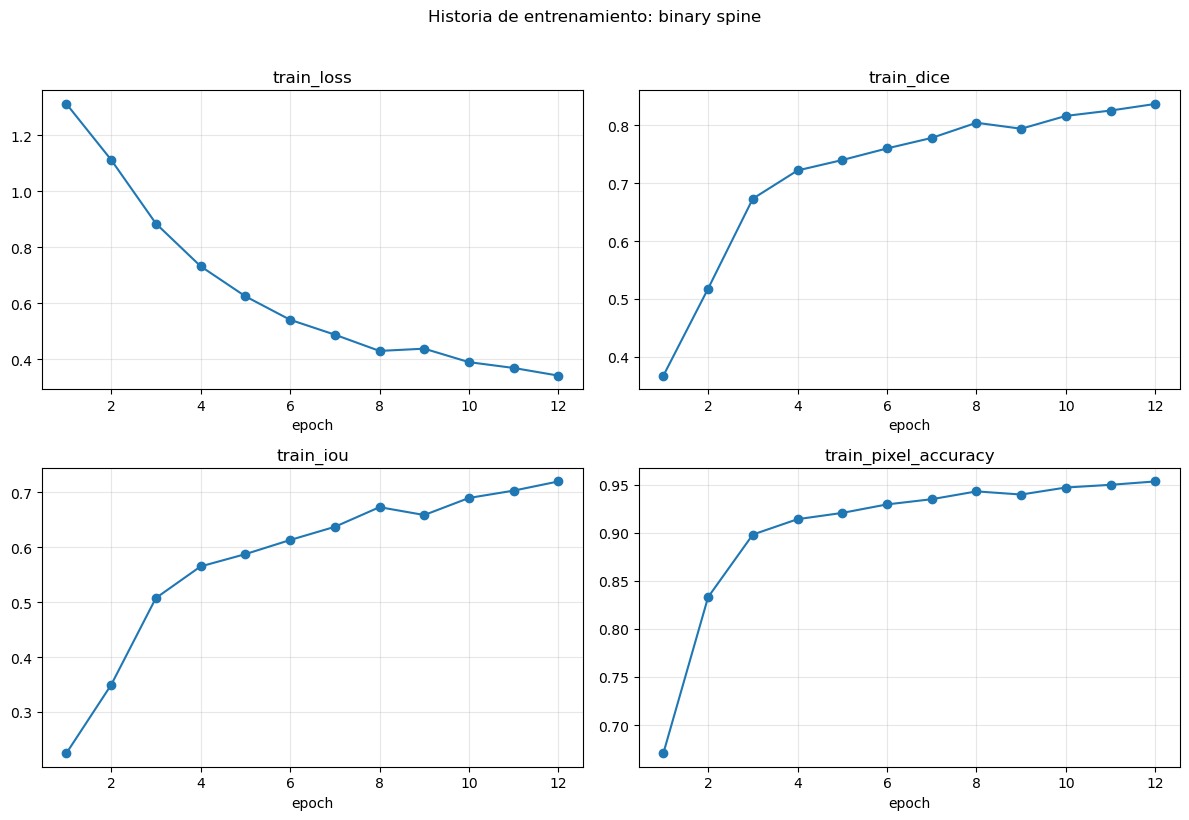

In [ ]:
binary_train_loader = DataLoader(
    binary_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
binary_test_loader = DataLoader(
    binary_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

binary_model = UNetSmall(in_channels=1, out_channels=1).to(DEVICE)
binary_optimizer = torch.optim.AdamW(binary_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
binary_bce = nn.BCEWithLogitsLoss()

binary_history = []
binary_start = time.time()

for epoch in range(1, BINARY_EPOCHS + 1):
    binary_model.train()
    epoch_loss = 0.0
    epoch_intersection = 0.0
    epoch_pred_area = 0.0
    epoch_target_area = 0.0
    epoch_correct = 0.0
    epoch_total_pixels = 0.0

    for batch in binary_train_loader:
        images = batch['image'].to(DEVICE)
        targets = batch['mask'].to(DEVICE)

        binary_optimizer.zero_grad()
        logits = binary_model(images)
        loss = binary_bce(logits, targets) + dice_loss_binary(logits, targets)
        loss.backward()
        binary_optimizer.step()

        epoch_loss += float(loss.item())
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        epoch_intersection += float((preds * targets).sum().item())
        epoch_pred_area += float(preds.sum().item())
        epoch_target_area += float(targets.sum().item())
        epoch_correct += float((preds == targets).sum().item())
        epoch_total_pixels += float(targets.numel())

    epoch_union = epoch_pred_area + epoch_target_area - epoch_intersection
    epoch_metrics = {
        'epoch': epoch,
        'train_loss': epoch_loss / max(len(binary_train_loader), 1),
        'train_dice': (2.0 * epoch_intersection + 1e-6) / (epoch_pred_area + epoch_target_area + 1e-6),
        'train_iou': (epoch_intersection + 1e-6) / (epoch_union + 1e-6),
        'train_pixel_accuracy': (epoch_correct + 1e-6) / (epoch_total_pixels + 1e-6),
    }
    binary_history.append(epoch_metrics)
    print(
        f"[Binary][Epoch {epoch:02d}/{BINARY_EPOCHS}] "
        f"loss={epoch_metrics['train_loss']:.4f} "
        f"dice={epoch_metrics['train_dice']:.4f} "
        f"iou={epoch_metrics['train_iou']:.4f} "
        f"acc={epoch_metrics['train_pixel_accuracy']:.4f}"
    )

binary_train_history_df = pd.DataFrame(binary_history)
binary_test_metrics = evaluate_binary(binary_model, binary_test_loader)
binary_elapsed_min = (time.time() - binary_start) / 60.0

binary_model_path = MODEL_DIR / 'binary_spine_unet_small.pt'
binary_history_path = OUTPUT_DIR / 'binary_spine_train_history.csv'
binary_test_metrics_path = OUTPUT_DIR / 'binary_spine_test_metrics.csv'

torch.save(binary_model.state_dict(), binary_model_path)
binary_train_history_df.to_csv(binary_history_path, index=False)
pd.DataFrame([binary_test_metrics]).to_csv(binary_test_metrics_path, index=False)

print('\nEntrenamiento binario finalizado')
print('Minutos aproximados:', round(binary_elapsed_min, 2))
print('Modelo guardado en:', binary_model_path)
print('Metricas de test:', binary_test_metrics)

display(binary_train_history_df.tail())
display(pd.DataFrame([binary_test_metrics]))
plot_history(binary_train_history_df, 'Historia de entrenamiento: binary spine')
show_binary_predictions(binary_model, binary_test_ds, n=3)

[Thoracolumbar-core][Epoch 01/18] loss=3.2846 macro_dice=0.0110 macro_iou=0.0056 acc=0.7179
[Thoracolumbar-core][Epoch 02/18] loss=2.8635 macro_dice=0.0000 macro_iou=0.0000 acc=0.8799
[Thoracolumbar-core][Epoch 03/18] loss=2.6219 macro_dice=0.0000 macro_iou=0.0000 acc=0.8803
[Thoracolumbar-core][Epoch 04/18] loss=2.4389 macro_dice=0.0017 macro_iou=0.0008 acc=0.8801
[Thoracolumbar-core][Epoch 05/18] loss=2.2904 macro_dice=0.0276 macro_iou=0.0146 acc=0.8742
[Thoracolumbar-core][Epoch 06/18] loss=2.1897 macro_dice=0.0502 macro_iou=0.0270 acc=0.8702
[Thoracolumbar-core][Epoch 07/18] loss=2.1263 macro_dice=0.0617 macro_iou=0.0333 acc=0.8708
[Thoracolumbar-core][Epoch 08/18] loss=2.1130 macro_dice=0.0593 macro_iou=0.0322 acc=0.8717
[Thoracolumbar-core][Epoch 09/18] loss=2.0853 macro_dice=0.0685 macro_iou=0.0372 acc=0.8717
[Thoracolumbar-core][Epoch 10/18] loss=2.0476 macro_dice=0.0817 macro_iou=0.0443 acc=0.8710
[Thoracolumbar-core][Epoch 11/18] loss=2.0117 macro_dice=0.0902 macro_iou=0.0502

,class_id,class_name,pixel_count,weight
0,0,background,18230394.0,0.250000
1,1,T1,93470.0,1.613923
2,2,T2,135428.0,1.113901
3,3,T3,129053.0,1.168926
4,4,T4,122361.0,1.232855
5,5,T5,134342.0,1.122906
6,6,T6,136262.0,1.107083
7,7,T7,141718.0,1.064462
8,8,T8,162219.0,0.929937
9,9,T9,158784.0,0.950054


,epoch,train_loss,train_pixel_accuracy,train_macro_dice_fg,train_macro_iou_fg
13,14,1.934695,0.870526,0.110620,0.062092
14,15,1.891818,0.870154,0.133808,0.075480
15,16,1.912773,0.867739,0.135545,0.076610
16,17,1.864392,0.869332,0.147255,0.083797
17,18,1.831108,0.871096,0.154782,0.088894


,loss,pixel_accuracy,macro_dice_fg,macro_iou_fg
0,1.876861,0.861238,0.15962,0.089837


,class_id,class_name,pred_pixels,target_pixels,dice,iou
0,0,background,4576889.0,4573778.0,9.626081e-01,9.279117e-01
1,1,T1,45406.0,24578.0,3.967478e-01,2.474644e-01
2,2,T2,25299.0,37944.0,3.036858e-01,1.790268e-01
3,3,T3,27714.0,34068.0,3.159173e-01,1.875901e-01
4,4,T4,13192.0,35091.0,1.173912e-01,6.235561e-02
5,5,T5,38670.0,35110.0,1.801572e-01,9.899604e-02
6,6,T6,47812.0,34666.0,1.848735e-01,1.018516e-01
7,7,T7,22571.0,47294.0,7.657625e-02,3.981247e-02
8,8,T8,47620.0,40104.0,1.282203e-01,6.850183e-02
9,9,T9,75788.0,48377.0,1.536021e-01,8.319012e-02


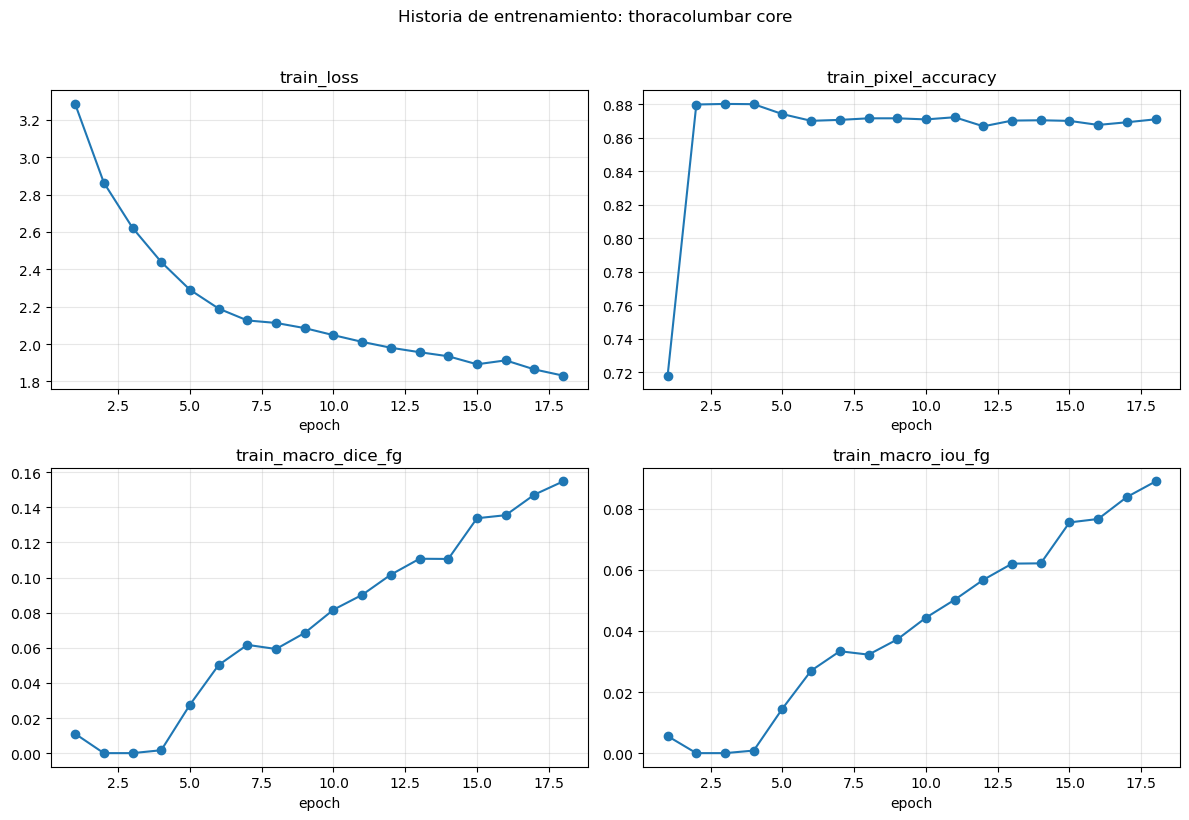

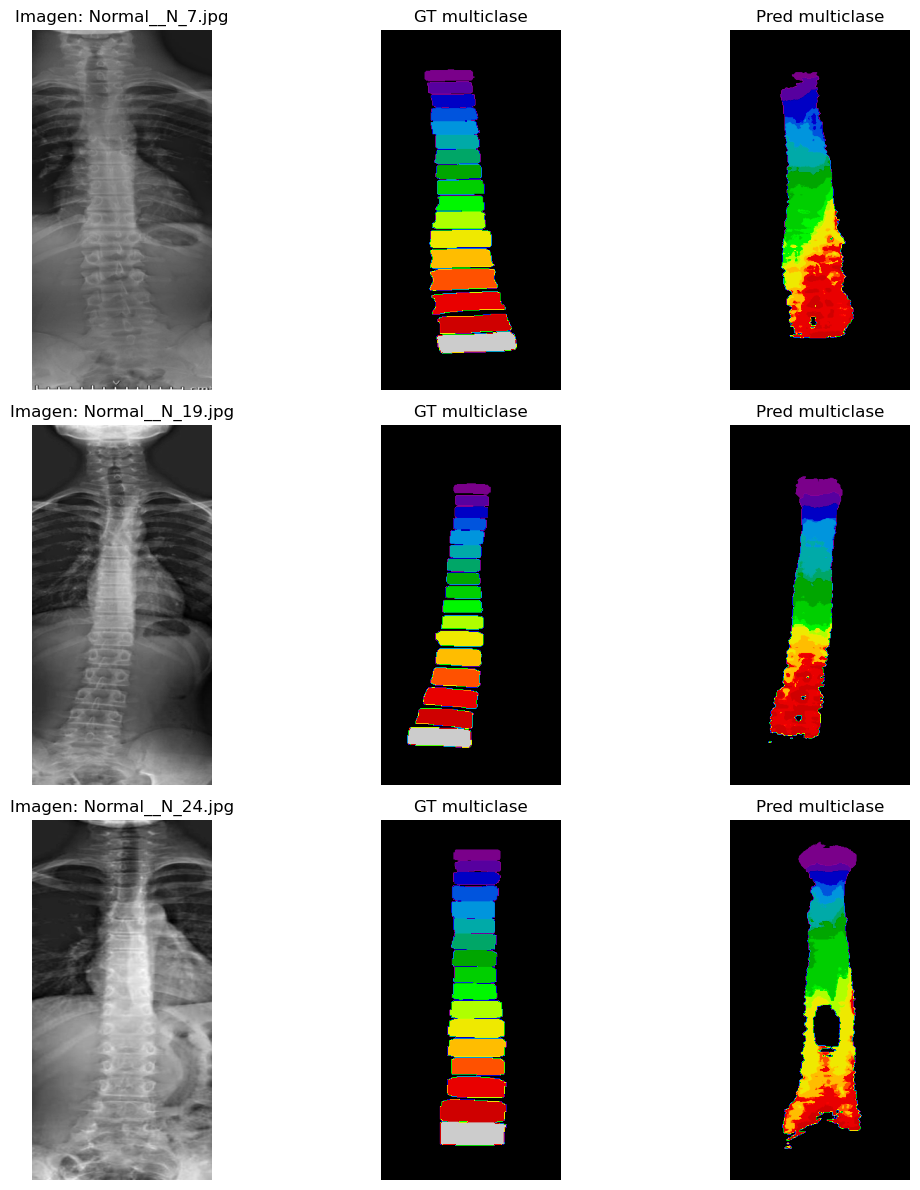

In [9]:
def estimate_multiclass_class_weights(table: pd.DataFrame) -> tuple[torch.Tensor, pd.DataFrame]:
    counts = np.ones(num_classes, dtype=np.float64)
    for _, row in table.iterrows():
        mask = build_multiclass_mask(row['multiclass_mask_path_abs'], IMG_SIZE)
        valid = mask != IGNORE_INDEX
        bincount = np.bincount(mask[valid].ravel(), minlength=num_classes)
        counts += bincount

    weights = counts.sum() / counts
    weights = weights / weights.mean()
    weights = np.clip(weights, 0.25, 8.0)
    weights_df = pd.DataFrame(
        {
            'class_id': np.arange(num_classes),
            'class_name': class_names,
            'pixel_count': counts,
            'weight': weights,
        }
    )
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE), weights_df


multiclass_train_loader = DataLoader(
    multiclass_train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
multiclass_test_loader = DataLoader(
    multiclass_test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

class_weights, class_weights_df = estimate_multiclass_class_weights(
    multiclass_splits_df.query("partition == 'train'")
)
multiclass_ce = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_INDEX)
multiclass_model = UNetSmall(in_channels=1, out_channels=num_classes).to(DEVICE)
multiclass_optimizer = torch.optim.AdamW(multiclass_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

multiclass_history = []
multiclass_start = time.time()

for epoch in range(1, MULTICLASS_EPOCHS + 1):
    multiclass_model.train()
    epoch_loss = 0.0
    epoch_correct = 0.0
    epoch_valid_pixels = 0.0
    epoch_intersection = np.zeros(num_classes, dtype=np.float64)
    epoch_pred_area = np.zeros(num_classes, dtype=np.float64)
    epoch_target_area = np.zeros(num_classes, dtype=np.float64)

    for batch in multiclass_train_loader:
        images = batch['image'].to(DEVICE)
        targets = batch['mask'].to(DEVICE)

        multiclass_optimizer.zero_grad()
        logits = multiclass_model(images)
        loss = multiclass_ce(logits, targets) + dice_loss_multiclass(
            logits, targets, num_classes=num_classes, ignore_index=IGNORE_INDEX
        )
        loss.backward()
        multiclass_optimizer.step()

        epoch_loss += float(loss.item())
        preds = torch.argmax(logits, dim=1)
        valid = targets != IGNORE_INDEX
        epoch_correct += float(((preds == targets) & valid).sum().item())
        epoch_valid_pixels += float(valid.sum().item())

        preds_np = preds[valid].detach().cpu().numpy()
        targets_np = targets[valid].detach().cpu().numpy()
        for class_idx in range(num_classes):
            pred_mask = preds_np == class_idx
            target_mask = targets_np == class_idx
            epoch_intersection[class_idx] += np.logical_and(pred_mask, target_mask).sum()
            epoch_pred_area[class_idx] += pred_mask.sum()
            epoch_target_area[class_idx] += target_mask.sum()

    epoch_dice = (2.0 * epoch_intersection + 1e-6) / (epoch_pred_area + epoch_target_area + 1e-6)
    epoch_iou = (epoch_intersection + 1e-6) / (epoch_pred_area + epoch_target_area - epoch_intersection + 1e-6)

    multiclass_history.append(
        {
            'epoch': epoch,
            'train_loss': epoch_loss / max(len(multiclass_train_loader), 1),
            'train_pixel_accuracy': (epoch_correct + 1e-6) / (epoch_valid_pixels + 1e-6),
            'train_macro_dice_fg': float(epoch_dice[1:].mean()),
            'train_macro_iou_fg': float(epoch_iou[1:].mean()),
        }
    )

    last_metrics = multiclass_history[-1]
    print(
        f"[Thoracolumbar-{MULTICLASS_SUBSET}][Epoch {epoch:02d}/{MULTICLASS_EPOCHS}] "
        f"loss={last_metrics['train_loss']:.4f} "
        f"macro_dice={last_metrics['train_macro_dice_fg']:.4f} "
        f"macro_iou={last_metrics['train_macro_iou_fg']:.4f} "
        f"acc={last_metrics['train_pixel_accuracy']:.4f}"
    )

multiclass_train_history_df = pd.DataFrame(multiclass_history)
multiclass_test_metrics, multiclass_per_class_df = evaluate_multiclass(
    multiclass_model, multiclass_test_loader, loss_fn=multiclass_ce
)
multiclass_elapsed_min = (time.time() - multiclass_start) / 60.0

multiclass_model_path = MODEL_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_unet_small.pt'
multiclass_history_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_train_history.csv'
multiclass_test_metrics_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_test_metrics.csv'
multiclass_per_class_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_per_class_metrics.csv'
multiclass_weights_path = OUTPUT_DIR / f'thoracolumbar_{MULTICLASS_SUBSET}_class_weights.csv'

torch.save(multiclass_model.state_dict(), multiclass_model_path)
multiclass_train_history_df.to_csv(multiclass_history_path, index=False)
pd.DataFrame([multiclass_test_metrics]).to_csv(multiclass_test_metrics_path, index=False)
multiclass_per_class_df.to_csv(multiclass_per_class_path, index=False)
class_weights_df.to_csv(multiclass_weights_path, index=False)

print('\nEntrenamiento multiclase finalizado')
print('Minutos aproximados:', round(multiclass_elapsed_min, 2))
print('Modelo guardado en:', multiclass_model_path)
print('Metricas globales de test:', multiclass_test_metrics)

display(class_weights_df)
display(multiclass_train_history_df.tail())
display(pd.DataFrame([multiclass_test_metrics]))
display(multiclass_per_class_df)
plot_history(multiclass_train_history_df, f'Historia de entrenamiento: thoracolumbar {MULTICLASS_SUBSET}')
show_multiclass_predictions(multiclass_model, multiclass_test_ds, n=3)

## Cómo leer los resultados (segmentación binaria, corrida V3)

Esta etapa predice **columna vs fondo** sobre radiografías en escala de grises redimensionadas (**512×256**). Las métricas guardadas corresponden al conjunto de **test** del split binario (20 % de grupos), salvo el historial, que es de **entrenamiento**.

### Dónde están los números

En `analysis_outputs_v3/training_runs_v3/`:

| Archivo | Qué contiene |
|---------|----------------|
| `binary_spine_test_metrics.csv` | Una fila con **loss**, **dice**, **iou**, **pixel_accuracy** en test. |
| `binary_spine_train_history.csv` | Por época: `train_loss`, `train_dice`, `train_iou`, `train_pixel_accuracy`. |
| `binary_spine_split_80_20.csv` | Qué muestras quedaron en `train` / `test` (split por `group_id_for_split`). |

El modelo entrenado suele guardarse en `models/` con nombre del estilo `binary_spine_unet_small.pt` (según la celda de guardado del notebook).

### Cómo interpretar cada métrica (binario)

- **Dice** y **IoU**: miden solapamiento entre máscara predicha y máscara binaria de referencia sobre la clase **columna**. Valores altos indican que la silueta de la columna está bien cubierta. El **IoU** suele ser más estricto que el Dice.
- **Pixel accuracy**: fracción de píxeles bien clasificados (fondo + columna). En radiografías el fondo es muy dominante, así que puede ser alta incluso con errores en el borde de la columna; por eso **no basta con mirar pixel accuracy**: hay que cruzarla con **Dice/IoU**.
- **Loss** (BCE + componente tipo Dice en el entrenamiento): sirve para ver tendencia en el historial; el valor absoluto en test es menos intuitivo que Dice/IoU.

### Lectura rápida de la corrida actual

En **test** se obtuvo aproximadamente **Dice ≈ 0,843**, **IoU ≈ 0,728** y **pixel accuracy ≈ 0,951** (ver `binary_spine_test_metrics.csv`). En el **último epoch de entrenamiento** el Dice de train ronda **0,837**, coherente con test (sin señal clara de sobreajuste fuerte en esta etapa).

El split aplicado fue **199 train / 50 test** sobre las muestras binarias utilizables.

> **Nota:** Si más adelante ejecutas también el bloque **multiclase** del mismo notebook, aparecerán archivos `thoracolumbar_<subset>_*.csv` con métricas distintas (por clase y macro sobre vértebras); su lectura es independiente de la binaria.


### Análisis e interpretación (segmentación binaria)

#### Resultados cuantitativos

Según `binary_spine_test_metrics.csv` y `binary_spine_train_history.csv` de esta corrida V3:

- **Test:** loss ≈ **0,346**; **Dice ≈ 0,843**; **IoU ≈ 0,728**; **pixel accuracy ≈ 0,951**.
- **Entrenamiento:** en **12 épocas**, el **train Dice** sube de ~0,37 (época 1) a ~**0,837** (época 12); la curva es en general **ascendente**, con una ligera oscilación en la época 9, típica del ruido por mini-batches.

La **brecha entre Dice de train (última época) y Dice de test (~0,843)** es pequeña: el modelo **generaliza** al conjunto de test reservado por grupos, lo cual es coherente con un split **80/20** por `group_id_for_split` que limita fuga paciente/imagen entre particiones.

#### Qué implica anatómicamente

Un **Dice ~0,84** en binario indica que la red **localiza de forma estable la región de columna** frente al fondo: es el comportamiento esperado para una primera etapa que sirve de **base geométrica** (delimitar dónde está la espina) antes de forzar al modelo a discriminar **17 etiquetas** vertebrales.

La **pixel accuracy ~0,95** debe interpretarse con cautela: el fondo ocupa mucha área; los errores relevantes para clínica o para etapas posteriores suelen estar en **bordes y extensión craneocaudal** de la máscara, donde **Dice/IoU** son más informativos.

#### Conclusiones

1. La **segmentación binaria V3 es un resultado sólido como baseline**: rendimiento alto y estable entre train y test en el protocolo actual.
2. No se observa un patrón obvio de **sobreajuste severo** solo a partir de estas cifras; la validación cualitativa (visualizaciones del notebook) sigue siendo recomendable en casos límite (campo reducido, contraste bajo).
3. Este resultado **justifica continuar con la etapa multiclase** (en este notebook o en un pipeline en cascada): la identificación **vértebra a vértebra** es un problema más difícil; disponer de una **columna bien localizada** (o una ROI derivada) es la dirección natural del proyecto.

#### Próximo paso sugerido

Ejecutar, cuando toque, el entrenamiento **thoracolumbar multiclase** y revisar los archivos `thoracolumbar_<subset>_*.csv` con el mismo criterio: priorizar **Dice/IoU por clase** y **macro sobre vértebras** frente a pixel accuracy global, dado el desbalance fondo/vértebra.


## Cómo leer los resultados (thoracolumbar multiclase, subset `core`, V3)

Esta etapa predice **18 clases** en la máscara: fondo + **T1–T12 + L1–L5**, sobre el subconjunto del manifiesto con `usable_for_thoracolumbar_core == True`. Las etiquetas fuera del target se mapean a `ignore_index` en entrenamiento (no se cuentan en la pérdida).

### Dónde están los números

En `analysis_outputs_v3/training_runs_v3/`:

| Archivo | Qué contiene |
|---------|----------------|
| `thoracolumbar_core_test_metrics.csv` | Una fila: **loss**, **pixel_accuracy**, **macro_dice_fg**, **macro_iou_fg** en test (promedio macro solo sobre clases de primer plano / vértebras). |
| `thoracolumbar_core_train_history.csv` | Por época: pérdida y métricas en **train**. |
| `thoracolumbar_core_per_class_metrics.csv` | Por **clase**: píxeles predichos vs GT, **Dice** e **IoU** (incluye `background`). |
| `thoracolumbar_core_class_weights.csv` | Frecuencia de píxeles por clase en train y **peso** usado en `CrossEntropyLoss` (acotado en el notebook). |
| `thoracolumbar_core_split_80_20.csv` | Asignación **train/test** por grupo para multiclase (solo filas core). |

### Cómo interpretar las métricas globales

- **macro_dice_fg** / **macro_iou_fg**: promedio de Dice/IoU sobre las **vértebras** (foreground), sin incluir fondo. Son las métricas más alineadas con “¿se identifica cada nivel?”. Valores bajos indican que el problema de **identidad vertebral** sigue siendo difícil aunque el fondo se acierte.
- **pixel_accuracy**: puede ser **alta** porque el **fondo** domina el área; no debe usarse sola para juzgar el multiclase.
- **Pesos por clase** (`thoracolumbar_core_class_weights.csv`): compensan desbalance; no sustituyen la dificultad de separar clases morfológicamente similares.

### Lectura rápida de esta corrida

- **Split core:** **158** train / **40** test (mismo esquema 80/20 por `group_id_for_split` sobre el subconjunto core).
- **Test (global):** loss ≈ **1,877**; pixel accuracy ≈ **0,861**; **macro_dice_fg ≈ 0,160**; **macro_iou_fg ≈ 0,090** (ver `thoracolumbar_core_test_metrics.csv`).
- El detalle **por vértebra** está en `thoracolumbar_core_per_class_metrics.csv` (incluye confusión vía `pred_pixels` vs `target_pixels`).


### Análisis e interpretación (thoracolumbar multiclase, subset `core`)

#### Resultados cuantitativos (test agregado)

Según `thoracolumbar_core_test_metrics.csv`:

- **macro_dice_fg ≈ 0,160** y **macro_iou_fg ≈ 0,090**: rendimiento **moderado/bajo** a nivel de identificación vertebral promedio.
- **pixel_accuracy ≈ 0,861**: coherente con un modelo que acierta mucho **fondo**; no contradice el macro bajo en vértebras.
- **loss ≈ 1,878** en test: conviene contrastarla con la tendencia del historial de train, no interpretarla aislada.

Según `thoracolumbar_core_train_history.csv`, en **18 épocas** el **train macro_dice_fg** sube desde valores casi nulos al inicio hasta ~**0,155** en la última época, en línea con el test (~0,160). Eso sugiere **poca brecha train–test en macro** al final; el problema principal no es un sobreajuste extremo, sino la **dificultad intrínseca** del multiclase y posibles **limitaciones de datos/etiqueta** en ciertas clases.

#### Hallazgos por clase (`thoracolumbar_core_per_class_metrics.csv`)

- **Fondo (`background`)**: Dice muy alto (~**0,963**), esperable y necesario para “rellenar” la imagen, pero **no** mide el objetivo clínico de etiquetar niveles.
- **Mejor desempeño relativo entre vértebras:** **T1** (Dice ~**0,397**), seguida de **T2** (~**0,304**) y **T3** (~**0,316**). Coincide con que la parte **superior** del campo suele ser más estable visualmente y con más píxeles de algunas clases en el agregado de test.
- **Clases muy débiles:** por ejemplo **T7** (Dice ~**0,077**), **T10** (~**0,096**), **L2** (~**0,086**), y en general varios niveles medios/bajos por debajo de 0,15–0,20.
- **Fallo crítico en L5:** en el agregado de test aparece **0 píxeles predichos** para **L5** frente a **~20k** píxeles en referencia (**Dice efectivamente ~0**). Es decir, el modelo **no asignó** la clase L5 en la evaluación agregada; es la señal más fuerte de que el multiclase **no es aún utilizable** para esa etiqueta sin cambios (datos, pérdida, ROI, arquitectura o postproceso).
- **Desajustes predicho vs objetivo** en otras clases (p. ej. **T12**: muchos más píxeles predichos que en GT) apuntan a **confusión entre niveles vecinos** y/o sesgo hacia ciertas etiquetas.

#### Peso de clases (`thoracolumbar_core_class_weights.csv`)

Los pesos corrigen frecuencias; **L5** tiene peso relativamente alto (~**1,18**) pero **no evitó** el colapso de predicción para L5 en test: el problema va más allá del solo reponderado (p. ej. rareza, solapamiento apariencia, o límites de resolución 512×256).

#### Conclusiones

1. El modelo multiclase **core** queda como **baseline de referencia**: separa algo de estructura vertebral en algunos niveles, pero **no alcanza** un nivel de desempeño homogéneo en T1–L5.
2. La **segmentación binaria** (Dice ~0,84 en la otra sección) y el **multiclase** (~0,16 macro en vértebras) no son comparables numéricamente: tareas distintas; la brecha refleja sobre todo **complejidad** y **desbalance** fondo/vértebra.
3. El **colapso de L5** obliga a tratar el multiclase actual como **no listo** para uso fino sin iteración: es un hallazgo accionable (revisión de máscaras, augmentación, **ROI/cascada** como en el otro notebook, o revisión de hiperparámetros).

#### Próximos pasos sugeridos (alineados con el proyecto)

- Usar **ROI** basada en binario (o el notebook en **cascada**) para que el multiclase opere con menos fondo y más resolución relativa en columna.
- Auditar **casos sin L5** en campo y **calidad de etiqueta** en bordes lumbares.
- Revisar **augmentación**, **más épocas**, u **otra arquitectura/encoder** si el curso lo permite; re-evaluar siempre con **macro por clase** y matrices de confusión, no solo con pixel accuracy.


### Tabla resumen — test multiclase (subset `core`, agregado sobre el split)

Métricas por clase desde `thoracolumbar_core_per_class_metrics.csv` (evaluación en **test**). Valores redondeados a 3 decimales.

| Clase | Dice | IoU | Píxeles predichos | Píxeles GT |
|-------|------|-----|-------------------|------------|
| background | 0.963 | 0.928 | 4,576,889 | 4,573,778 |
| T1 | 0.397 | 0.247 | 45,406 | 24,578 |
| T2 | 0.304 | 0.179 | 25,299 | 37,944 |
| T3 | 0.316 | 0.188 | 27,714 | 34,068 |
| T4 | 0.117 | 0.062 | 13,192 | 35,091 |
| T5 | 0.180 | 0.099 | 38,670 | 35,110 |
| T6 | 0.185 | 0.102 | 47,812 | 34,666 |
| T7 | 0.077 | 0.040 | 22,571 | 47,294 |
| T8 | 0.128 | 0.069 | 47,620 | 40,104 |
| T9 | 0.154 | 0.083 | 75,788 | 48,377 |
| T10 | 0.096 | 0.050 | 29,366 | 51,811 |
| T11 | 0.115 | 0.061 | 29,348 | 48,914 |
| T12 | 0.194 | 0.108 | 125,735 | 56,479 |
| L1 | 0.121 | 0.064 | 39,786 | 45,230 |
| L2 | 0.086 | 0.045 | 18,713 | 44,062 |
| L3 | 0.136 | 0.073 | 49,172 | 36,917 |
| L4 | 0.107 | 0.057 | 29,799 | 28,131 |
| L5 | 0.000 | 0.000 | 0 | 20,326 |

**Nota:** `macro_dice_fg` / `macro_iou_fg` en el CSV global de test promedian solo sobre vértebras (foreground); esta tabla incluye **background** para lectura completa.

#### Por qué se plantea el notebook en cascada (`train_spine_cascade_binary_to_thoracolumbar_v3.ipynb`)

El entrenamiento **multiclase sobre imagen completa** (este notebook) deja un **macro Dice en vértebras bajo** (~0,16 en test) y problemas claros **por clase**: confusión entre niveles vecinos, **colapso de predicción en L5** (cero píxeles predichos frente al GT) y **pixel accuracy alta** que enmascara el rendimiento real al dominar el fondo. Eso indica que el cuello de botella no es solo el desbalance de píxeles, sino que la segunda red debe resolver **localización fina y clasificación fina al mismo tiempo** sobre un campo visual muy grande.

El notebook **`train_spine_cascade_binary_to_thoracolumbar_v3.ipynb`** implementa una **mejora metodológica** explícita: primero entrena la **segmentación binaria** (columna vs fondo) y luego, usando una **ROI** derivada de esa etapa —en validación/test, ROI **predicha** por el binario— entrena el **multiclase solo sobre el recorte** de columna. Así se **reduce la proporción de fondo** en la ventana vista por la U-Net multiclase, se acerca el entrenamiento al **uso real** (localizar columna y luego etiquetar niveles) y se alinea con la evidencia de este baseline: cuando el multiclase “plano” falla en lumbares y niveles medios, la **cascada binario → ROI → multiclase** es la estrategia documentada para **mejorar la relación señal/ruido** y la estabilidad de las clases raras antes de iterar en augmentación o arquitecturas más pesadas.
